In [109]:
import QUANTAXIS as QA
from QUANTAXIS.QAData import QA_DataStruct_Stock_block
from QUANTAXIS.QAUtil import  trade_date_sse
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np

import DescTools as dt
import seaborn as sns

__LOW_FREQUENCE__ = [QA.FREQUENCE.YEAR, QA.FREQUENCE.QUARTER, QA.FREQUENCE.MONTH, QA.FREQUENCE.WEEK, QA.FREQUENCE.DAY]   

    

class Hy:
    def __init__(self,hytype='tdxhy', end='2021-03-19', gap=60, start=None, frequence=QA.FREQUENCE.DAY):
        self._hy_type=hytype
        self.end = end
        self.gao = gap
        if start is None:
            self.start = trade_date_sse[trade_date_sse.index(end)-gap]
        else:
            self.start = start
        self.blocks_view = self.get_blocks_view()
        self.pivot = None
        self.frequence = frequence
        
    @property
    def hy_type(self):
        return self._hy_type
    
    @hy_type.setter
    def hy_type(self, value):
        if not value in ['tdxhy','swhy','gn']:
            raise TypeError('hy_type MUST BE [tdxhy|swhy|gn]')
        self._hy_type=value
        self.blocks_view = self.get_blocks_view()
        
    @property
    def is_low_frequence(self):
        return self.frequence in __LOW_FREQUENCE__

    
    def fit(self, blocks=None):
        if blocks is None or blocks == 'all':
            ma_above = self.blocks_view.apply(self.check_MA_above)
        elif isinstance(blocks, list):
            ma_above = self.blocks_view[blocks].apply(self.check_MA_above)
        else:
            raise TypeError('fit(blocks) params error')
        tmp = ma_above.reset_index()
        if self.is_low_frequence:
            date_label = 'date'
        else:
            date_label = 'datetime'
        rebuid_df = pd.DataFrame({'blockname':tmp.blockname.repeat(tmp[0].str.len()),date_label:[i[0] for i in np.concatenate(tmp[0].values)],'-':[i[1] for i in np.concatenate(tmp[0].values)]})
        self.pivot = rebuid_df.pivot(index=date_label, columns='blockname')
        print('hangye pivot fit finish')

        
    def get_blocks_view(self):
        a = QA.QA_fetch_stock_block_adv().data
        blocks_view = a[a['type'] == self._hy_type].groupby(level=0).apply(
            lambda x:[item for item in x.index.remove_unused_levels().levels[1]]
        )
        return blocks_view
    
    def check_MA_above(self, hy_codes):
        try:
            data = QA.QA_quotation(hy_codes, self.start, self.end, source=QA.DATASOURCE.MONGO,
                               frequence=self.frequence, market=QA.MARKET_TYPE.STOCK_CN,
                               output=QA.OUTPUT_FORMAT.DATASTRUCT)
        except Exception as e:
            print(e)
            return []

        close = data.close
        count = len(hy_codes)
        compared = close[19*count:] > close.groupby(level=1).apply(lambda x: QA.MA(x, 20))[19*count:]
        if self.is_low_frequence:
            date_label = 'date'
        else:
            date_label = 'datetime'
        res = compared.groupby(level=0).apply(lambda x: (x.index.get_level_values(date_label)[0], round(np.sum(x)/len(x),2)))
        return res.values
    
    def plot(self):
        formater = '%Y%m%d' if self.is_low_frequence else '%Y%m%d %H%M%S'
        y_label = [pd.to_datetime(x).strftime(formater) for x in self.pivot.index.values]
        stock_in_block_s = self.blocks_view.apply(lambda x:len(x))
        xlabel = [columns[1]+'('+str(stock_in_block_s[columns[1]])+')' for columns in hy.pivot.columns]

        block_count = len(self.pivot.columns)
        
        if block_count > 100:
            self._plot(self.pivot.iloc[:,0:int(block_count/2)], y_label, xlabel[0:int(block_count/2)])
            self._plot(self.pivot.iloc[:,int(block_count/2):block_count], y_label, xlabel[int(block_count/2):block_count])
        else:
            self._plot(self.pivot, y_label, xlabel)
    
    def _plot(self,data,y_label,xlabel):
        width = 40*len(data.columns)
        high = 15*len(data.index)
        if width > 2100:width = 2100
#         if high < 520:high = 520
        fig = plt.figure(figsize=(width/72,high/72))
        ax = sns.heatmap(data,fmt='.2f', yticklabels=y_label, xticklabels=xlabel, 
                         linewidths=0.5,cbar=False,cmap='YlGnBu')
        plt.xticks(rotation = -90)
        plt.show()


In [110]:
%%time
hy = Hy(hytype='tdxhy', end='2021-03-19', gap=1, frequence=QA.FREQUENCE.FIFTEEN_MIN)
hy.fit()

hangye pivot fit finish
Wall time: 16.7 s


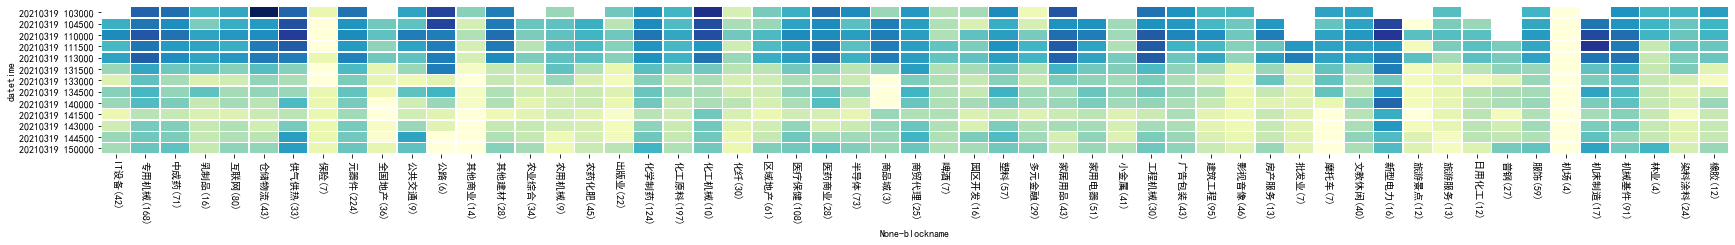

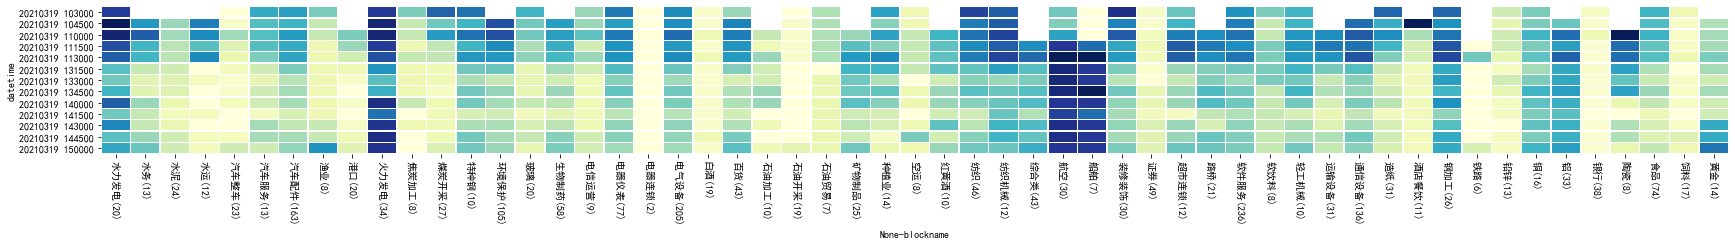

Wall time: 2.4 s


In [111]:
%%time
hy.plot()

In [90]:
len(hy.pivot.index)

125

In [81]:
hy.blocks_view
QA.FREQUENCE?

Init signature: QA.FREQUENCE()
Docstring:     
查询的级别

YEAR = 'year'  # 年bar
QUARTER = 'quarter'  # 季度bar
MONTH = 'month'  # 月bar
WEEK = 'week'  # 周bar
DAY = 'day'  # 日bar
ONE_MIN = '1min'  # 1min bar
FIVE_MIN = '5min'  # 5min bar
FIFTEEN_MIN = '15min'  # 15min bar
THIRTY_MIN = '30min'  # 30min bar
HOUR = '60min'  # 60min bar
SIXTY_MIN = '60min'  # 60min bar
TICK = 'tick'  # transaction
ASKBID = 'askbid'  # 上下五档/一档
REALTIME_MIN = 'realtime_min' # 实时分钟线
LATEST = 'latest'  # 当前bar/latest

2019/08/06 @yutiansut
File:           d:\pyprojects\quantaxis\quantaxis\qautil\qaparameter.py
Type:           type
